In [9]:
from pathlib import Path
import torch
import decord
import numpy as np
import cv2
import av
from typing import List, Optional, Dict, Tuple
import matplotlib.pyplot as plt

from cotracker.predictor import CoTrackerOnlinePredictor, CoTrackerPredictor

In [2]:
# Load CoTracker model (online)
device = "cuda" if torch.cuda.is_available() else "cpu"
ckpt_path = "/home/ubuntu/playground/spinflow/external/co-tracker/checkpoints/scaled_online.pth"

MAX_QUERY_POINTS = 384
WINDOW_SIZE = 2 # frames between samples
model = CoTrackerOnlinePredictor(
    checkpoint=ckpt_path
).to(device)

In [3]:
# Replace with your video path
video_path = "/home/ubuntu/playground/spinflow/data/fai_spinflow_raw/output_rides_2025-08-04-15-14-00/ride_ferrite4_2025-08-04-15-33-13_0/front_camera.mp4"
START_FRAME=500

decord.bridge.set_bridge("torch")
vr = decord.VideoReader(video_path, ctx=decord.cpu(0))
video_length = len(vr)
END_FRAME=min(START_FRAME+100, video_length)

video = vr.get_batch(range(START_FRAME, END_FRAME)).to(device)
video = video.permute(0, 3, 1, 2).unsqueeze(0)  # (1, T, C, H, W)
video = video.flip(dims=[1])  # (1, T, C, H, W)

print("Video shape:", video.shape, "Max value:", video.max(), " Datatype ", video.dtype)

Video shape: torch.Size([1, 100, 3, 480, 640]) Max value: tensor(255, device='cuda:0', dtype=torch.uint8)  Datatype  torch.uint8


In [12]:

from scipy.interpolate   import UnivariateSpline
from scipy.spatial       import cKDTree
from scipy.ndimage       import gaussian_filter1d

DEBUG_MASK = False

def build_mask_from_crumbs(
    img_bgr: np.ndarray,
    tracks: np.ndarray,          # (K,2)
    crumb_times: np.ndarray,     # (K,)
    sides: np.ndarray,           # (K,)
    *,
    # spline_smooth: float = 150.0,
    # resolution: int = 24,        # arc-len px per dense point
    # blur_sigma: float = 5.0,     # σ for Gaussian smoothing of width curve
    # min_width_frac: float = 0.2, # never collapse below this × global median
    # spoke_length: int = 20,
    # Tight turns sparse
    spline_smooth: float = 50.0,
    resolution: int = 20,        # arc-len px per dense point
    blur_sigma: float = 5.0,     # σ for Gaussian smoothing of width curve
    min_width_frac: float = 0.45, # never collapse below this × global median
    spoke_length: int = 15,
    viz_path: str = "centerline_viz.png",
) -> np.ndarray:
    """Return bool mask (H,W) covering the swept path.  Saves debug PNG."""
    H, W = img_bgr.shape[:2]
    default_output = {"mask": None, "success": False}
    # ───────────────────────────── 1. filter NaNs
    ok = (np.isfinite(tracks).all(1) &
          np.isfinite(crumb_times)    &
          np.isfinite(sides))
    if not np.any(ok):
        if DEBUG_MASK:
            print("build_mask_from_crumbs: no valid crumbs found")
        return default_output
    tracks, crumb_times, sides = tracks[ok], crumb_times[ok], sides[ok]

    # ───────────────────────────── 2-3. left/right centroids per int timestamp
    out = get_center_spline(
        tracks, crumb_times, sides, spline_smooth=spline_smooth
    )
    if out is None:
        if DEBUG_MASK:
            print("build_mask_from_crumbs: failed to compute center spline")
        return default_output

    Lc, Rc, Mc, ts, cx, cy, px, py = (
        out["Lc"], out["Rc"], out["Mc"],
        out["ts"], out["cx"], out["cy"],
        out["px"], out["py"]
    )

    # ───────────────────────────── 4. debug overlay (unchanged)
    viz = img_bgr.copy()
    for p in Lc.astype(int): cv2.circle(viz, tuple(p), 3, (255, 0, 0), -1)
    for p in Rc.astype(int): cv2.circle(viz, tuple(p), 3, (  0, 0,255), -1)
    for p in Mc.astype(int): cv2.circle(viz, tuple(p), 3, (  0,255, 0), -1)
    cv2.polylines(viz, [np.round(np.c_[cx, cy]).astype(int)], False, (255,255,0), 2)
    for (mx, my), (nx, ny) in zip(Mc.astype(int), zip(px, py)):
        p1 = (mx + int(nx * spoke_length), my + int(ny * spoke_length))
        p2 = (mx - int(nx * spoke_length), my - int(ny * spoke_length))
        cv2.line(viz, (mx, my), p1, (0,255,255), 1)
        cv2.line(viz, (mx, my), p2, (0,255,255), 1)

    # ───────────────────────────── 5. densify along centreline (just to pick a density)
    seg     = np.hypot(np.diff(cx), np.diff(cy))
    s       = np.concatenate(([0.], np.cumsum(seg)))
    total   = s[-1]
    n_dense = max(int(total / resolution) + 1, 3 * len(s))

    # ───────────────────────────── 6. fit two splines to Lc and Rc
    ts_min, ts_max = ts[0], ts[-1]
    ts_d = np.linspace(ts_min, ts_max, n_dense)

    try:
        # side splines (reuse same smoothing knob)
        sxL = UnivariateSpline(ts, Lc[:,0], k=3, s=spline_smooth)
        syL = UnivariateSpline(ts, Lc[:,1], k=3, s=spline_smooth)
        sxR = UnivariateSpline(ts, Rc[:,0], k=3, s=spline_smooth)
        syR = UnivariateSpline(ts, Rc[:,1], k=3, s=spline_smooth)
    except Exception as e:
        print("build_mask_from_crumbs: spline fit failed:", e)
        return default_output

    # evaluate dense left/right
    left_xy  = np.vstack([sxL(ts_d), syL(ts_d)]).T
    right_xy = np.vstack([sxR(ts_d), syR(ts_d)]).T
    
    # ───────────────────────────── 7. smooth each rail
    left_xy[:,0]  = gaussian_filter1d(left_xy[:,0],  blur_sigma, mode="nearest")
    left_xy[:,1]  = gaussian_filter1d(left_xy[:,1],  blur_sigma, mode="nearest")
    right_xy[:,0] = gaussian_filter1d(right_xy[:,0], blur_sigma, mode="nearest")
    right_xy[:,1] = gaussian_filter1d(right_xy[:,1], blur_sigma, mode="nearest")

    def extrapolate_to_bottom(xy):
        p0, p1 = xy[-2], xy[-1]
        dx, dy = p1 - p0
        if dy == 0:
            new = np.array([p1[0], H-1])
        else:
            t   = (H-1 - p1[1]) / dy
            new = p1 + t*np.array([dx, dy])
        return np.vstack([xy, new])

    left_xy  = extrapolate_to_bottom(left_xy)
    right_xy = extrapolate_to_bottom(right_xy)

    # ───────────────────────────── 7. debug‐draw the two rails
    cv2.polylines(viz, [np.round(left_xy ).astype(int)], False, (0,255,0), 2)
    cv2.polylines(viz, [np.round(right_xy).astype(int)], False, (0,0,255), 2)
    cv2.imwrite(viz_path, viz)

    # ───────────────────────────── 8. fill between them
    poly = np.vstack([left_xy, right_xy[::-1]])
    mask = np.zeros((H, W), np.uint8)
    if poly.shape[0] >= 3:
        cv2.fillPoly(mask, [np.round(poly).astype(np.int32)], 255)

    # ───────────────────────────── 8b. health‐check & fallback
    # a) fraction of crumbs covered
    pts = np.round(tracks).astype(int)
    pts[:,0] = np.clip(pts[:,0], 0, W-1)
    pts[:,1] = np.clip(pts[:,1], 0, H-1)
    inside = mask[pts[:,1], pts[:,0]]
    frac_in = float(inside.sum()) / len(inside)

    # b) convex‐hull of crumbs (fallback geometry)
    hull_pts = cv2.convexHull(tracks.astype(np.int32))
    hull_mask = np.zeros_like(mask, np.uint8)
    cv2.fillConvexPoly(hull_mask, hull_pts, 255)

    # d) carve out small holes 
    open_radius = 5  # tweak as needed
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE, (2*open_radius+1, 2*open_radius+1)
    )
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    # ───────────────────────────── 8e. keep only the largest connected component
    cc_count, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    if cc_count > 1:                                    # 0 = background
        areas          = stats[1:, cv2.CC_STAT_AREA]    # skip background
        largest_label  = 1 + np.argmax(areas)           # restore offset
        mask           = np.where(labels == largest_label, 255, 0).astype(np.uint8)

    # ───────────────────────────── 8f. re-evaluate health metrics
    # a) fraction of crumbs covered
    inside   = mask[pts[:, 1], pts[:, 0]]
    frac_in  = float(inside.sum()) / len(inside)

    # b) convex hull of crumbs (same as before)
    mask_area = float(mask.sum())
    hull_area = float(hull_mask.sum()) + 1e-6
    solidity  = mask_area / hull_area

    # decide failure
    COVERAGE_THRESH = 0.7    # e.g. at least 70% of crumbs must lie inside
    SOLIDITY_THRESH = 0.4   # ribbon must fill ≥40% of its convex hull
    if frac_in < COVERAGE_THRESH or solidity < SOLIDITY_THRESH:
        # fallback to simple hull
        if DEBUG_MASK:
            print(f"Mask failure: frac_in={frac_in:.2f}, solidity={solidity:.2f}")
        return { "mask": (hull_mask > 0), "success": False }

    # ───────────────────────────── 9. all good
    return { "mask": mask.astype(bool), "success": True }

def get_center_spline(
    tracks: np.ndarray,
    crumb_times: np.ndarray,
    sides: np.ndarray,
    spline_smooth: float,
):
    """
    Return (Lc, Rc, Mc, ts, cx, cy, px, py) or None on failure.
    - Lc/Rc: (N,2) left / right centroids per integer timestamp
    - Mc   : centre pts ½(Lc+Rc)
    - ts   : timestamps used for spline fit  (float64)
    - cx,cy: centre spline evaluated at ts
    - px,py: unit normals at ts  (for debug spokes)
    """
    try:
        ok = (np.isfinite(tracks).all(1) &
            np.isfinite(crumb_times)    &
            np.isfinite(sides))
        if not np.any(ok):
            return None
        tracks, crumb_times, sides = tracks[ok], crumb_times[ok], sides[ok]

        t0, t1 = int(np.ceil(crumb_times.min())), int(np.floor(crumb_times.max()))
        Lc, Rc, Mc, ts_mid = [], [], [], []
        for t in range(t0, t1 + 1):
            iL = np.where((crumb_times.astype(int) == t) & (sides == -1))[0]
            iR = np.where((crumb_times.astype(int) == t) & (sides == +1))[0]
            if iL.size and iR.size:
                cL, cR = tracks[iL].mean(0), tracks[iR].mean(0)
                Lc.append(cL); Rc.append(cR); Mc.append((cL + cR) * 0.5); ts_mid.append(t)
        if len(Mc) < 2:
            return None

        Lc, Rc, Mc = map(np.vstack, (Lc, Rc, Mc))
        ts = np.asarray(ts_mid, float)

        # smooth centre spline --------------------------------------------------
        sx = UnivariateSpline(ts, Mc[:, 0], k=3, s=spline_smooth)
        sy = UnivariateSpline(ts, Mc[:, 1], k=3, s=spline_smooth)
        cx, cy = sx(ts), sy(ts)

        # unit normal at sparse points
        dx, dy = sx.derivative()(ts), sy.derivative()(ts)
        nrm    = np.hypot(dx, dy); nrm[nrm == 0] = 1.0
        px, py = -dy / nrm, dx / nrm
    except Exception as e:
        if DEBUG_MASK:
            print("get_center_spline: error:", e)
        return None

    return {
        "Lc": Lc, "Rc": Rc, "Mc": Mc,
        "ts": ts, "cx": cx, "cy": cy,
        "px": px, "py": py
    }

In [13]:
def local_eq(gray):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    return clahe.apply(gray)

def sift_in_mask(
    video_rgb: np.ndarray,
    n_samples: int,
    seg_mask: Optional[np.ndarray] = None,
    sift_kwargs: Optional[Dict[str, float]] = None
) -> Dict[str, np.ndarray]:
    """
    Extract up to `n_samples` SIFT keypoints per frame, using a single pass:
     - If seg_mask is all ones (or None), we enforce half-left/half-right sampling.
     - Otherwise we simply take the top-n responses within the mask.
    """
    assert video_rgb.ndim == 4 and video_rgb.shape[-1] == 3
    N, H, W, _ = video_rgb.shape
    assert n_samples > 0

    # Prepare the mask flag
    if seg_mask is None:
        use_full_mask = True
    else:
        assert seg_mask.shape == (N, H, W)
        use_full_mask = bool(seg_mask.all())

    # Default SIFT args
    default_kwargs = {
        "nfeatures": 0,
        "edgeThreshold": 15,
        "sigma": 1.6,
        "nOctaveLayers": 5,
        "contrastThreshold": 0.015,
    }
    sift = cv2.SIFT_create(**(sift_kwargs or default_kwargs))

    # Outputs
    coords   = np.full((N, n_samples, 2), np.nan, dtype=np.float32)
    sides    = np.zeros((N, n_samples),       dtype=np.float32)
    coverage = np.zeros(N, dtype=int)

    for i in range(N):
        # 1) grayscale + local equalization
        gray = cv2.cvtColor(video_rgb[i], cv2.COLOR_RGB2GRAY)
        gray = local_eq(gray)

        # 2) choose mask
        mask_arg = None if use_full_mask else seg_mask[i].astype(np.uint8)

        # 3) detect & compute
        kps, _ = sift.detectAndCompute(gray, mask_arg)
        if not kps:
            continue

        # 4) pts & responses
        pts       = np.array([kp.pt for kp in kps], dtype=np.float32)      # (M,2)
        responses = np.array([kp.response for kp in kps], dtype=np.float32) # (M,)

        M = pts.shape[0]
        if use_full_mask:
            # ---- split into left/right ----
            left_idx  = np.where(pts[:,0] < (W/2))[0]
            right_idx = np.where(pts[:,0] >= (W/2))[0]

            n_left  = n_samples // 2
            n_right = n_samples - n_left

            # sort each side by response
            left_sorted  = left_idx[np.argsort(responses[left_idx])[::-1]]
            right_sorted = right_idx[np.argsort(responses[right_idx])[::-1]]

            pick_left  = left_sorted[:n_left]
            pick_right = right_sorted[:n_right]

            picked = np.concatenate([pick_left, pick_right])
            # if we still have slots, fill from the remaining best
            if picked.size < n_samples:
                remaining = np.setdiff1d(np.argsort(responses)[::-1], picked, assume_unique=True)
                to_fill   = n_samples - picked.size
                picked    = np.concatenate([picked, remaining[:to_fill]])

        else:
            # ---- unrestricted top-n ----
            order  = np.argsort(responses)[::-1]
            picked = order[:n_samples]

        # 5) write out
        Kkeep = min(picked.size, n_samples)
        selected_pts = pts[picked[:Kkeep]]
        coords[i, :Kkeep]    = selected_pts
        coverage[i]          = Kkeep
        sides[i, :Kkeep]     = np.where(selected_pts[:, 0] < (W/2), -1.0, 1.0)

    return {"keyps": coords, "sides": sides, "coverage": coverage}

def sample_sift_mask(video, max_num_points, mask=None, window_size=20, sift_kwargs=None):
    """Inputs
        video: (B, T, 3, H, W) torch tensor of video frames
        mask: (H, W) np array of mask to apply to the video frames
    Return:
        queries: (1, N*K, 3) torch tensor of queries where N is #windows, K is #keypoints
                 each query is (t, x, y)
        sides:   (1, N*K) torch tensor of side‐ids
    """
    assert video.ndim == 5 and video.shape[2] == 3, \
        "Video must be in (B, T, 3, H, W) format"

    # 1) Convert to H×W×3 numpy
    video = video[0].permute(0, 2, 3, 1).cpu().numpy()
    if video.max() <= 1.0:
        video = (video * 255).astype(np.uint8)
    else:
        video = video.astype(np.uint8)
    T, H, W, _ = video.shape

    # 2) Prepare mask
    if mask is None:
        mask = np.ones((H, W), dtype=bool)
    else:
        assert mask.shape == (H, W), f"Mask must be {H}×{W}, got {mask.shape}"
    video_mask = np.repeat(mask[None, :, :], T, axis=0)

    # 3) Pick one frame per window (uniformly), include first & last
    num_windows = max(1, T // window_size)
    idxs = np.linspace(0, T - 1, num=num_windows, dtype=int)
    idxs = np.unique(np.concatenate(([0], idxs, [T - 2])))
    
    sub_video      = video[idxs]
    sub_video_mask = video_mask[idxs]

    # 4) Run SIFT only on those frames
    samples_per_frame = max(384, int(max_num_points / len(idxs)))
    sift_dict = sift_in_mask(
        sub_video,
        n_samples=samples_per_frame,
        seg_mask=sub_video_mask,
        sift_kwargs=sift_kwargs
    )

    # 5) Build queries exactly as before, but using our subsampled frames `idxs`
    keyps       = sift_dict['keyps']   # shape (N_w, K, 2)
    sides       = sift_dict['sides']   # shape (N_w, K)
    Nw, K, _    = keyps.shape
    # repeat each timestamp K times
    ts          = np.repeat(idxs[:, None], K, axis=1)
    queries_np  = np.concatenate([ts[..., None], keyps], axis=2).reshape(-1, 3)
    sides_np    = sides.reshape(-1)

    # 6) filter out any NaNs
    valid_mask  = ~np.isnan(queries_np).any(axis=1)
    queries_np  = queries_np[valid_mask]
    sides_np    = sides_np[valid_mask]

    # 7) to tensors and return
    crumb_queries     = torch.from_numpy(queries_np).float().unsqueeze(0)   # (1, M, 3)
    crumb_query_sides = torch.from_numpy(sides_np).float().unsqueeze(0)    # (1, M)

    print(f"Crump queries shape: {crumb_queries.shape}")
    return crumb_queries, crumb_query_sides

def get_trapezoid_mask(H, W, grid_width, grid_height, sample_at_edges):
    """Compute a trapezoidal mask"""
    mask = np.zeros((H, W), dtype=np.uint8)
    # Define the trapezoid vertices
    left_top_x = W // 2 - grid_width // 2
    right_top_x = W // 2 + grid_width // 2
    top_left = (left_top_x, H - grid_height)
    top_right = (right_top_x, H - grid_height)

    offset = (right_top_x - left_top_x) * 0.2  # 20% offset for the bottom
    bottom_left = (left_top_x - offset, H)
    bottom_right = (right_top_x + offset, H)

    # Fill the trapezoid area
    pts = np.array([top_left, top_right, bottom_right, bottom_left], np.int32)
    cv2.fillPoly(mask, [pts], 255)

    if sample_at_edges:
        inner_offset = (right_top_x - left_top_x) * 0.3  # 30% offset for the inner edges
        pts = np.array([
            (top_left[0] + inner_offset, top_left[1]),
            (top_right[0] - inner_offset, top_right[1]),
            (bottom_right[0] - inner_offset, bottom_right[1]),
            (bottom_left[0] + inner_offset, bottom_left[1]),
        ], np.int32)
        negative_mask = np.ones((H, W), dtype=np.uint8) * 255  # Reset mask to full
        cv2.fillPoly(negative_mask, [pts], 0)  # Fill the inner trapezoid area
        mask = cv2.bitwise_and(mask, negative_mask)  # Apply the negative mask
    cv2.imwrite("trapezoid_mask.jpg", mask)  # Save for debugging
    return mask

def draw_video_masks(
    video: torch.Tensor,    
    tracks: torch.Tensor,
    visibility: torch.Tensor,
    crumbs: torch.Tensor,
    crumb_sides: torch.Tensor,
    save_video: bool = False,
    filename: str = "annotated_video.mp4"
):
    """Draws masks on the video frames based on the tracks and visibility."""
    assert video.ndim == 5, "Video must be in (B, T, C, H, W) format"
    assert tracks.ndim == 4, "Tracks must be in (B, T, N, 2) format"
    assert visibility.ndim == 3, "Visibility must be in (B, T, N) format"
    assert crumbs.ndim == 3, "Crumbs must be in (B, N, 3) format"
    assert crumb_sides.ndim == 2, "Crumb sides must be in (B, N) format"
    B, T, _, H, W = video.shape

    crumb_times = crumbs[:, :, 0].int().cpu().numpy()  # Shape (B, N) for crumb times
    crumb_sides = crumb_sides.cpu().numpy()

    video = video[0].permute(0, 2, 3, 1).cpu().numpy().astype(np.uint8)  # Convert to numpy array
    annotated_video = video.copy()  # Copy the video to draw on
    
    # For each frame, draw the trajectory masks using the visible points
    # for idx, frame in enumerate(video):
    for idx in range(T):
        frame = np.ascontiguousarray(video[idx])  # Ensure contiguous memory layout for OpenCV
        ftracks = tracks[0, idx].cpu().numpy()  # Shape (N, 2) for the current frame
        fvisibility = visibility[0, idx].cpu().numpy()  # Shape (N,)

        # override for testing
        fvisibility = np.ones_like(fvisibility, dtype=np.float32)  # All visible for testing

        # Filter all tracks, crumbs, and times by visibility
        visible_mask = fvisibility > 0
        ftracks = ftracks[visible_mask]  # Shape (N_visible, 2)
        fcrumb_times = crumb_times[0, visible_mask]  # Shape (N_visible, 3)
        fcrumb_sides = crumb_sides[0, visible_mask]  # Shape (N_visible,)

        mask = build_mask_from_crumbs(
            frame, ftracks, fcrumb_times, fcrumb_sides
        )["mask"]
        if mask is None:
            print(f"No visible crumbs in frame {idx}, skipping mask drawing.")
            continue

        # Draw the mask on the frame
        overlay_mask = annotated_video[idx].copy()  # Copy the frame to draw on
        overlay_mask[mask] = (51, 255, 255)
        annotated_video[idx] = cv2.addWeighted(
            annotated_video[idx], 0.5, overlay_mask, 0.5, 0)
        
        # Draw current tracks on frame
        for track in ftracks:
            x, y = int(track[0]), int(track[1])
            if 0 <= x < W and 0 <= y < H:
                cv2.circle(annotated_video[idx], (x, y), radius=3, color=(0, 255, 0), thickness=-1)
    if save_video:
        success = save_video_np(annotated_video, filename)
        if success:
            print(f"Annotated video saved to {filename}")

def save_video_np(
        video: np.ndarray, path: str, fps: int = 15,
        codec: str = 'h264', quality: int = 20
    ) -> None:
    """
    video: (N, H, W, 3) uint8 ndarray
    """
    path = Path(path)
    assert video.ndim == 4 and video.shape[-1] == 3, "video must be (N, H, W, 3)"
    assert video.dtype == np.uint8, "video must be uint8"
    assert path.suffix in ['.mp4', '.avi', '.mov'], \
        "path must end with .mp4, .avi, or .mov"

    if not path.parent.exists():
        path.parent.mkdir(parents=True, exist_ok=True)

    container = av.open(path, mode='w', format='mp4')
    stream = container.add_stream(codec, rate=fps, options={
        'preset': 'medium',  # 'ultrafast', 'fast', 'medium', 'slow', 'veryslow'
        'crf': str(quality),  # Constant Rate Factor (0-51, lower is better quality)
    })
    stream.width = video.shape[2]
    stream.height = video.shape[1]
    stream.pix_fmt = 'yuv420p'

    for frame in video:
        frame_av = av.VideoFrame.from_ndarray(frame, format='rgb24')
        packet = stream.encode(frame_av)
        container.mux(packet)

    # flush the encoder
    packet = stream.encode()
    if packet:
        container.mux(packet)

    container.close()
    return True

In [5]:
%matplotlib inline
H, W = video.shape[3], video.shape[4]
grid_w = W * 0.25
grid_h = H * 0.15
# qmask = get_trapezoid_mask(H, W, grid_w, grid_h, sample_at_edges=True)
qmask = np.ones((H, W), dtype=np.uint8)
# Show binary query mask
# plt.imshow(qmask, cmap='gray')
crumbs, crumb_sides = sample_sift_mask(
    video, MAX_QUERY_POINTS, qmask,
    # sift_kwargs={"edgeThreshold": 100, "sigma": 1.6,
    #              "nOctaveLayers": 3, "contrastThreshold": 0.09},
    sift_kwargs=None,
    window_size=WINDOW_SIZE)
crumbs = crumbs.to(device)  # (1, N, 3)
crumb_sides = crumb_sides.to(device)  # (1, N)
print("Crumbs shape:", crumbs.shape, "Sides shape:", crumb_sides.shape)

Crump queries shape: torch.Size([1, 19584, 3])
Crumbs shape: torch.Size([1, 19584, 3]) Sides shape: torch.Size([1, 19584])


torch.Size([1, 100, 3, 480, 640])


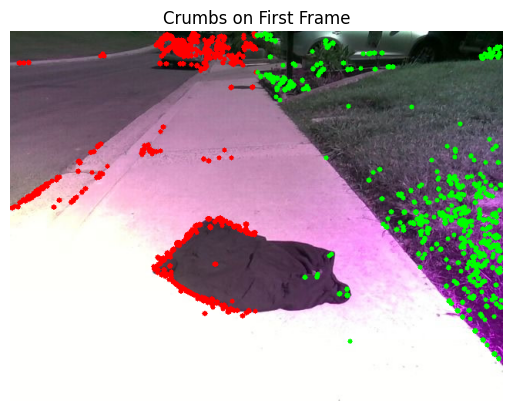

In [7]:
%matplotlib inline
# Draw crumbs on the first frame for visualization
import matplotlib.pyplot as plt
print(video.shape)
frame=80
first_frame = video[0, frame].cpu().numpy().transpose(1, 2, 0)  # (H, W, C)
for i in range(crumbs.shape[1]):
    x, y = crumbs[0, i, 1], crumbs[0, i, 2]
    side = crumb_sides[0, i].item()
    color = (255, 0, 0) if side < 0 else (0, 255, 0)  # Red for left, Green for right
    cv2.circle(first_frame, (int(x), int(y)), radius=3, color=color, thickness=-1)
plt.imshow(first_frame)
plt.axis('off')
plt.title("Crumbs on First Frame")
plt.show()

In [8]:
video_th = video.float()
model(video_chunk=video_th, is_first_step=True,
          grid_size=0, queries=crumbs, add_support_grid=True)

T = video.shape[1]
for ind in range(0, T - model.step, model.step):
    pred_tracks, pred_visibility = model(
        video_chunk=video_th[:, ind: ind + model.step * 2],
        grid_size=0, queries=crumbs, add_support_grid=True)



In [14]:
draw_video_masks(
    video_th,              # (1, L, C, H, W)
    pred_tracks,            # (1, L, N_crumb, 2)  ← was t_all (mismatched N)
    pred_visibility,            # (1, L, N_crumb)     ← was v_all (mismatched N)
    crumbs,            # (1, N_crumb, 3)
    crumb_sides,     # (1, N_crumb)
    save_video=True,
    filename="test_output.mp4"
)

Annotated video saved to test_output.mp4
